In [19]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import glob

from statsmodels.robust import mad
from scipy.stats import pearsonr

from muldoon.read_data import *
from muldoon.utils import *
from local_utils import *

help(get_RDS_data)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Help on function get_RDS_data in module local_utils:

get_RDS_data(sol, data_dir='../data/data_calibrated_env/')
    Returns the time in LTST and RDS dataset for a given sol

    Args:
        sol (int): desired sol
        data_dir (str): path to files

    Returns:
        time, RDS_data



In [20]:
# Read in vortices
vortex_data = "WE__0090___________CAL_RDS__________________P01.csv"
# Read in data file - We just have the one for now.
desired_sol = 90
time, RDS_data = get_RDS_data(desired_sol, data_dir="./")
print(RDS_data.dtype.names)

Processing file: .\sol_0090\WE__0090___________CAL_RDS_________________P01.csv
('SCLK', 'LMST', 'LTST', 'RDS_LAT_1', 'RDS_LAT_2', 'RDS_LAT_3', 'RDS_LAT_4', 'RDS_LAT_5', 'RDS_LAT_6', 'RDS_LAT_7', 'RDS_LAT_8', 'RDS_TOP_1', 'RDS_TOP_2', 'RDS_TOP_3', 'RDS_TOP_4', 'RDS_TOP_5', 'RDS_TOP_6', 'RDS_TOP_7', 'RDS_TOP_8', 'RDS_LAT_1_HG', 'RDS_LAT_2_HG', 'RDS_LAT_3_HG', 'RDS_LAT_4_HG', 'RDS_LAT_5_HG', 'RDS_LAT_6_HG', 'RDS_LAT_7_HG', 'RDS_LAT_8_HG', 'RDS_TOP_1_HG', 'RDS_TOP_2_HG', 'RDS_TOP_3_HG', 'RDS_TOP_4_HG', 'RDS_TOP_5_HG', 'RDS_TOP_6_HG', 'RDS_TOP_7_HG', 'RDS_TOP_8_HG', 'ROVER_HGA_STILL', 'ROVER_STILL')


In [14]:
# Removed this from above cell
print(RDS_data['SCLK'])

[674883875 674883876 674883877 ... 674969284 674969285 674969286]


In [15]:
# print(RDS_data.dtype.names)
# plt.scatter(time, RDS_data['RDS_LAT_7'])
print(vortex_data[4])
# ind = vortex_data['sol'] == desired_sol
# for i in range(len(vortex_data['sol'][ind])):
#     plt.axvline(vortex_data['t0'][ind][i])

0


TypeError: string indices must be integers, not 'str'

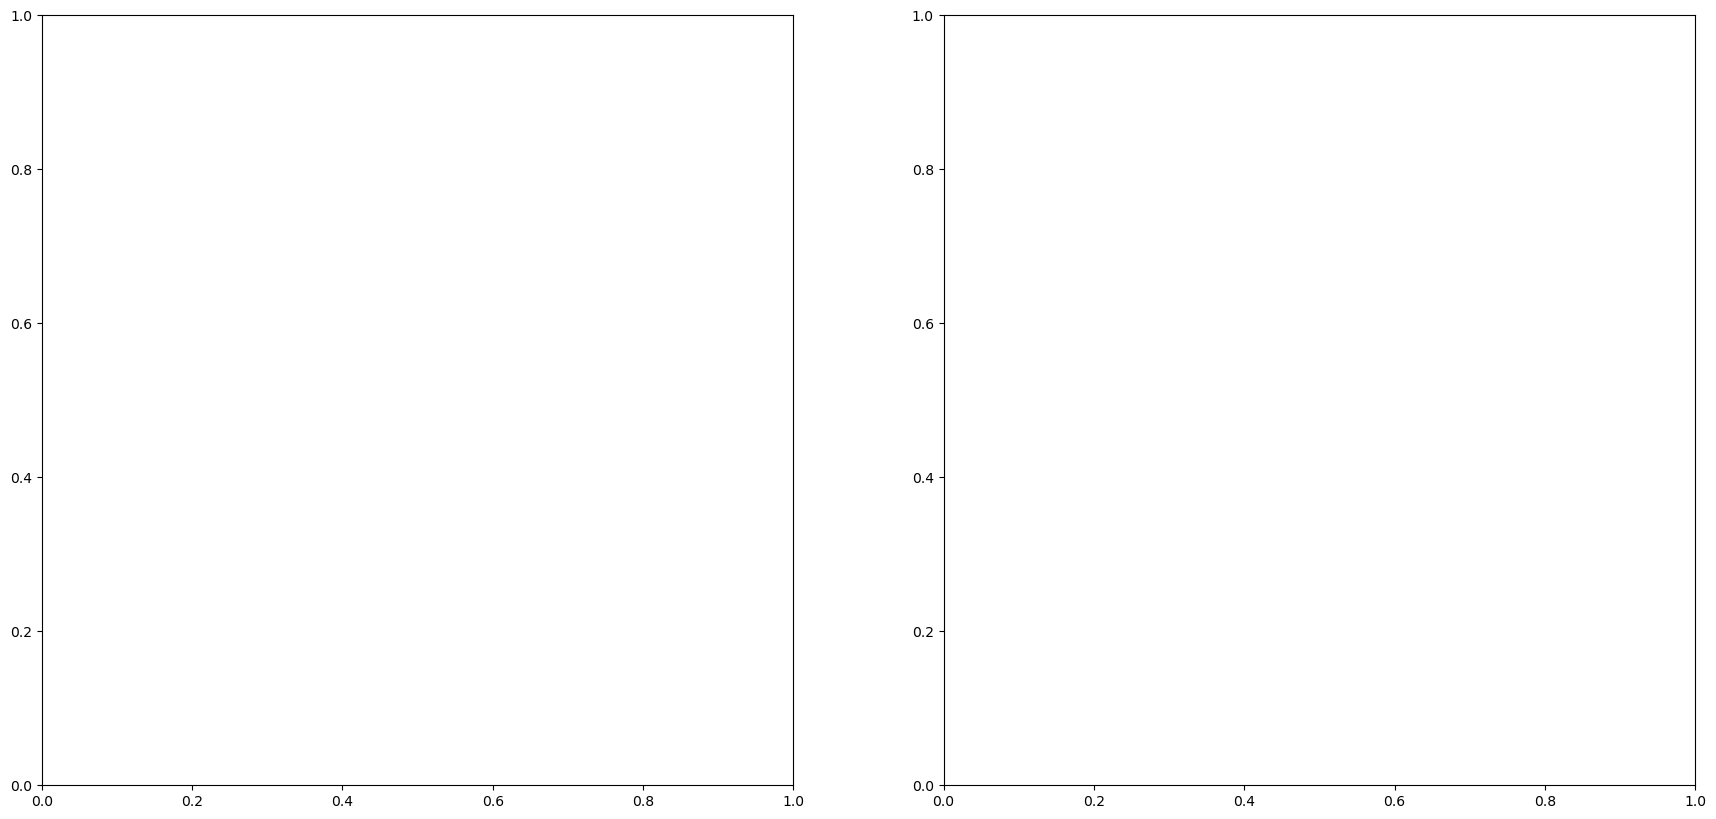

In [18]:
# Plot showing good correlation between RDS and vortex and bad correlation
import itertools

fig = plt.figure(figsize=(12*aspect_ratio, 10))
ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

line_colors = itertools.cycle((BoiseState_blue, BoiseState_orange, 'green', 'red', 'purple', 'goldenrod'))

# Read in vortices
vortex_data = "WE__0090___________CAL_RDS__________________P01.csv"

### Good correlation for sol 82's biggest vortex ###

# Read in data file - We just have the one for now.
# desired_sol = 90
#time, RDS_data = get_RDS_data(desired_sol)
ind = vortex_data['sol'] == desired_sol
oind = np.abs(time - vortex_data['t0'][ind][0]) < 3.*vortex_data['Gamma'][ind][0]/3600.

# Make sensors that are co-located plot together
for sensor_number in range(2, 8):

    cur_line_color = next(line_colors)
    
    lat_sensor_name = "RDS_LAT_%i" % sensor_number
    top_sensor_name = "RDS_TOP_%i" % sensor_number
    ax.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
               (RDS_data[lat_sensor_name][oind] -\
                np.nanmedian(RDS_data[lat_sensor_name][oind]))/np.nanmedian(RDS_data[lat_sensor_name][oind]), 
            lw=3, color=cur_line_color, label=lat_sensor_name)
    
    ax.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
           (RDS_data[top_sensor_name][oind] -\
            np.nanmedian(RDS_data[top_sensor_name][oind]))/np.nanmedian(RDS_data[top_sensor_name][oind]), 
        lw=3, ls='--', color=cur_line_color, label=top_sensor_name)
    
# And then the last sensor
ax.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
       (RDS_data['RDS_TOP_8'][oind] -\
        np.nanmedian(RDS_data['RDS_TOP_8'][oind]))/np.nanmedian(RDS_data['RDS_TOP_8'][oind]), 
    lw=3, ls='--', color='black', label='RDS_TOP_8')

# # The maximum departure
# print(np.max(np.abs((RDS_data['RDS_TOP_8'][oind] -\
#         np.nanmedian(RDS_data['RDS_TOP_8'][oind]))/np.nanmedian(RDS_data['RDS_TOP_8'][oind]))))

ax.axvspan(-0.5*vortex_data['Gamma'][ind][0], 0.5*vortex_data['Gamma'][ind][0], color='lightgrey', zorder=-1)
ax.legend(fontsize=18, loc='lower right')
ax.tick_params(labelsize=24)
ax.set_xlabel(r'$t - t_0\,\left( {\rm s} \right)$', fontsize=36)
ax.set_ylabel(r'$\left( F - \overline{F} \right)/\overline{F}$', fontsize=36)

# Format LTST
hour = int(np.floor(vortex_data['t0'][ind][0]))
mn = np.floor((vortex_data['t0'][ind][0] - hour)*60)
ax.set_title(r'sol = %s, $t_0 = $%i:%02i LTST' %\
        (desired_sol, hour, mn), fontsize=30)
ax.text(-20, -0.25, "(a)", fontsize=75)
ax.grid(True)

### Bad correlation for sol 30's biggest vortex

desired_sol = 90
time, RDS_data = get_RDS_data(desired_sol)
ind = vortex_data['sol'] == desired_sol
oind = np.abs(time - vortex_data['t0'][ind][0]) < 3.*vortex_data['Gamma'][ind][0]/3600.

# Make sensors that are co-located plot together
for sensor_number in range(2, 8):

    cur_line_color = next(line_colors)
    
    lat_sensor_name = "RDS_LAT_%i" % sensor_number
    top_sensor_name = "RDS_TOP_%i" % sensor_number
    ax2.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
               (RDS_data[lat_sensor_name][oind] -\
                np.nanmedian(RDS_data[lat_sensor_name][oind]))/np.nanmedian(RDS_data[lat_sensor_name][oind]), 
            lw=3, color=cur_line_color, label=lat_sensor_name)
    
    ax2.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
           (RDS_data[top_sensor_name][oind] -\
            np.nanmedian(RDS_data[top_sensor_name][oind]))/np.nanmedian(RDS_data[top_sensor_name][oind]), 
        lw=3, ls='--', color=cur_line_color, label=top_sensor_name)
    
# And then the last sensor
ax2.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
       (RDS_data['RDS_TOP_8'][oind] -\
        np.nanmedian(RDS_data['RDS_TOP_8'][oind]))/np.nanmedian(RDS_data['RDS_TOP_8'][oind]), 
    lw=3, ls='--', color='black', label='RDS_TOP_8')

# # The maximum departure
# print(np.max(np.abs((RDS_data['RDS_TOP_8'][oind] -\
#         np.nanmedian(RDS_data['RDS_TOP_8'][oind]))/np.nanmedian(RDS_data['RDS_TOP_8'][oind]))))

ax2.axvspan(-0.5*vortex_data['Gamma'][ind][0], 0.5*vortex_data['Gamma'][ind][0], color='lightgrey', zorder=-1)
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.tick_params(labelsize=24, labelright=True)
ax2.set_xlabel(r'$t - t_0\,\left( {\rm s} \right)$', fontsize=36)
ax2.set_ylabel(r'$\left( F - \overline{F} \right)/\overline{F}$', fontsize=36)

# Format LTST
hour = int(np.floor(vortex_data['t0'][ind][0]))
mn = np.floor((vortex_data['t0'][ind][0] - hour)*60)
ax2.set_title(r'sol = %s, $t_0 = $%i:%02i LTST' %\
        (desired_sol, hour, mn), fontsize=30)
ax2.text(-400, -0.57, "(b)", fontsize=75)
ax2.grid(True)

fig.tight_layout()
# fig.savefig("../figures/vortex_RDS_example.jpg", dpi=300, bbox_inches="tight")